# Statistical Downscaling Using ML: An Introductory Example 

### Redouane Lguensat<sup>1</sup> and Kazem Ardaneh<sup>2</sup>

<sup>1</sup> Climate Modeling Center, Sorbonne University, IRD, IPSL, Paris, France 

<sup>2</sup> Climate Modeling Center, Sorbonne University, CNRS, IPSL, Paris, France 

---

## Abstract

This notebook guides a practical use of **IPSL-AID**, a generative downscaling tool. While the full IPSL-AID framework downscales multiple atmospheric variables with uncertainty quantification, this introductory tutorial focuses on a **light deterministic baseline**: a U-Net trained to reconstruct original 2m temperature fields from their coarsened versions. 

---

## 1. Introduction

### 1.1 Why downscaling?

Global Climate Models (GCMs) typically operate at spatial resolutions of 150-200 km, which is insufficient to capture essential regional processes shaped by topography, land-sea contrast, and surface heterogeneity. **Statistical downscaling** addresses this limitation by learning relationships between large-scale predictors and local-scale variables.

### 1.2 What IPSL-AID offers?

The IPSL-AID framework (Kingston et al., 2026) introduces:

| Feature | Description |
|---------|-------------|
| **Generative approach** | Denoising Diffusion Probabilistic Models (DDPMs)|
| **Multi-variable** | Downscales T2m, 10U, 10V, precipitation, etc |
| **Uncertainty quantification** | Ensemble generation with CRPS, rank histograms, spread-skill ratios |
| **Global applicability** | Random block sampling strategy enables training on global data without retraining for new regions |

### 1.3 This tutorial's scope

| Full IPSL-AID | This Tutorial |
|---------------|----------------|
| Diffusion models | Deterministic U-Net (baseline) |
| 6 variables  | Single variable (2m temperature) |
| Uncertainty quantification | Point predictions only |
| Residual learning (CU + R') | Direct mapping |
| 100 epochs, 6 days on 4×NVIDIA A100 | 15 epochs on single NVIDIA RTX A5000 |


---

## 2. Overview

### 2.1 Formulation

Let $\mathbf{y}^{\mathrm{HR}}$ be a high-resolution (HR) field. The input is a **coarse-up (CU)** approximation obtained by:

1. Bilinear interpolation to coarse resolution (comparable to GCM output)
2. Interpolation back to HR grid

The CU field preserves large-scale structure while eliminating small-scale variability:

$$\mathbf{y}^{\mathrm{CU}} = \text{Up}(\text{Down}(\mathbf{y}^{\mathrm{HR}}))$$


### 2.2 Architecture

This tutorial uses a **Song U-Net** (DDPM++ architecture) with:
- Input: CU temperature field (1 channel)
- Output: High-resolution temperature field (1 channel)
- Skip connections for fine-grained spatial detail transfer

### 2.3 Training Strategy

| Component | Setting |
|-----------|---------|
| Train years | 2015-2019 (7,304 samples) |
| Validation year | 2020 (1,464 samples) |
| Test year | 2021 (1,460 samples) |
| Batch size | 16 |
| Optimizer | AdamW (lr=1e-3) |
| Scheduler | ReduceLROnPlateau |
| Epochs | 15 |

### 2.4 Normalization

Per-pixel normalization using training set statistics:
$$x_{\mathrm{norm}} = \frac{x - \mu_{\mathrm{train}}}{\sigma_{\mathrm{train}}}$$

---

## 3. Data

### 3.1 ERA5 Reanalysis

| Property | Value |
|----------|-------|
| Source | WeatherBench2 (Google Cloud Storage) |
| Variable | 2m temperature (T2m) |
| Native resolution | 1.5° × 1.5° |
| Temporal resolution | 6-hourly |
| Period | 2012-2021 |

### 3.2 Resolution

| Dimension | Points | Step | Approx. distance at equator |
|-----------|--------|------|----------------------------|
| Longitude | 240 | 1.5° | ~166 km |
| Latitude | 121 | 1.5° | ~166 km |

### 3.3 Coarsening

We coarsen the ERA5 2m temperature field using the `coarse_down_up` function from IPSL_AID. This function:
1. Downscales the fine-resolution field to a coarse grid (16 × 32, ~2.25° resolution, comparable to GCMs)
2. Upsamples back to original resolution via bilinear interpolation

The goal is to solve the inverse problem:

$$t2m_{HR} = \mathbf{F}(t2m_{CU})$$

where `t2m_{CU}` is the coarse approximation that preserves large-scale structure but loses fine-scale variability.

---

## 4. Metrics

### 4.1 Deterministics

| Metric | Definition |
|--------|------------|
| MAE | $\mathrm{MAE} = \frac{1}{N}\sum_{n=1}^{N} \|y_n - \hat{y}_n\|$ |
| RMSE | $\mathrm{RMSE} = \sqrt{\frac{1}{N}\sum_{n=1}^{N}(y_n - \hat{y}_n)^2}$ |
| $R^2$ | $R^2 = 1 - \frac{\sum_{n=1}^{N}(y_n - \hat{y}_n)^2}{\sum_{n=1}^{N}(y_n - \bar{y})^2}$ |
| Pearson $r$ | $r = \frac{\mathrm{cov}(y,\hat{y})}{\sigma_y \sigma_{\hat{y}}}$ |

### 4.2 Distributionals

- **Probability Density Function (PDF)**: Statistical distribution fidelity
- **Kullback-Leibler (KL) divergence**: Quantifies difference between predicted and reference PDFs
- **Power Spectral Density (PSD)**: Recovery of spatial variability across scales

### 4.3 Baseline

The trivial baseline is the coarsed input field itself. A successful model must beat this baseline across all metrics, particularly in high-wavenumber (fine-scale) spectral content.

---

## 5. Expected Results

Based on the IPSL-AID paper, the diffusion model achieves:

| Variable | MAE | RMSE | $R^2$ | CRPS |
|----------|-----|------|-------|------|
| T2m | $0.44 \pm 0.02$ K | $0.71 \pm 0.04$ K | 1.00 | $0.25 \pm 0.01$ K |
| 10U | $0.52 \pm 0.02$ m/s | $0.79 \pm 0.03$ m/s | 0.98 | $0.29 \pm 0.01$ m/s |
| 10V | $0.50 \pm 0.01$ m/s | $0.74 \pm 0.03$ m/s | 0.98 | $0.28 \pm 0.01$ m/s |
| TP | $0.10 \pm 0.00$ mm/hr | - | 0.68 | $0.04$ mm/hr |


---

## 6. Limitations

- **Deterministic only**: No uncertainty quantification (ensemble sampling not implemented)
- **Single variable**: Does not capture inter-variable physical consistency
- **Short training period**: 5 years vs. multi-decadal climate timescales

### 6.1 Extensions

| Extension | Description |
|-----------|-------------|
| **Diffusion model** | Replace U-Net with a diffusion model sampler for generative downscaling |
| **Multi-variable** | Add wind and precipitation with joint training |
| **Ensemble prediction** | Generate multiple plausible realizations for uncertainty |
| **CMIP6 application** | Apply to future climate projections with bias correction |
| **Regional focus** | Adapt to specific domains (e.g., complex terrain, coastal zones) |


# Installation

## Install IPSL-AID

In [1]:
!pip install --no-deps --force-reinstall --no-cache-dir \
git+https://github.com/kardaneh/IPSL-AID.git

Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/kardaneh/IPSL-AID.git to /tmp/pip-req-build-raoop48b
  Running command git clone --filter=blob:none --quiet https://github.com/kardaneh/IPSL-AID.git /tmp/pip-req-build-raoop48b
  Resolved https://github.com/kardaneh/IPSL-AID.git to commit 5db958e2c69718040d9f5518e8520bca4a2c3d97
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ipsl-aid: filename=ipsl_aid-0.1.0-py3-none-any.whl size=135706 sha256=9edfe99371768c42b93f3f227d88516d13578b9b6a63f7350ac62f843f0e5be7
  Stored in directory: /tmp/pip-ephem-wheel-cache-334s5jrj/wheels/6a/82/97/a1de0671520898d5d101f5e1b210bf6efd2b0a9b9ce1e08a66
Successfully built ipsl-aid
  Attempting uninstall: ipsl-aid
    Found existing installation: ipsl-aid 0.1.0
    Uninstalling ipsl-aid-0.1.0:
      Successfully uninstalled ipsl-aid-0.1.0


## Install additional dependencies

In [2]:
!pip install zarr gcsfs

Defaulting to user installation because normal site-packages is not writeable


# ERA5 data

In [3]:
import xarray as xr

obs_path = "gs://weatherbench2/datasets/era5/1959-2022-6h-240x121_equiangular_with_poles_conservative.zarr"

ds = xr.open_zarr(
    obs_path,
    chunks=-1,
    storage_options=dict(token="anon"),
)

ds

<xarray.Dataset> Size: 1TB
Dimensions:                                           (time: 92040,
                                                       longitude: 240,
                                                       latitude: 121, level: 13)
Coordinates:
  * time                                              (time) datetime64[ns] 736kB ...
  * longitude                                         (longitude) float64 2kB ...
  * latitude                                          (latitude) float64 968B ...
  * level                                             (level) int64 104B 50 ....
Data variables: (12/38)
    10m_u_component_of_wind                           (time, longitude, latitude) float32 11GB dask.array<chunksize=(92040, 240, 121), meta=np.ndarray>
    10m_v_component_of_wind                           (time, longitude, latitude) float32 11GB dask.array<chunksize=(92040, 240, 121), meta=np.ndarray>
    10m_wind_speed                                    (time, longitude, latitude) float32 11GB dask.array<chunksize=(92040, 240, 121), meta=np.ndarray>
    2m_temperature                                    (time, longitude, latitude) float32 11GB dask.array<chunksize=(92040, 240, 121), meta=np.ndarray>
    angle_of_sub_gridscale_orography                  (longitude, latitude) float32 116kB dask.array<chunksize=(240, 121), meta=np.ndarray>
    anisotropy_of_sub_gridscale_orography             (longitude, latitude) float32 116kB dask.array<chunksize=(240, 121), meta=np.ndarray>
    ...                                                ...
    type_of_high_vegetation                           (longitude, latitude) float32 116kB dask.array<chunksize=(240, 121), meta=np.ndarray>
    type_of_low_vegetation                            (longitude, latitude) float32 116kB dask.array<chunksize=(240, 121), meta=np.ndarray>
    u_component_of_wind                               (time, level, longitude, latitude) float32 139GB dask.array<chunksize=(92040, 13, 240, 121), meta=np.ndarray>
    v_component_of_wind                               (time, level, longitude, latitude) float32 139GB dask.array<chunksize=(92040, 13, 240, 121), meta=np.ndarray>
    vertical_velocity                                 (time, level, longitude, latitude) float32 139GB dask.array<chunksize=(92040, 13, 240, 121), meta=np.ndarray>
    wind_speed                                        (time, level, longitude, latitude) float32 139GB dask.array<chunksize=(92040, 13, 240, 121), meta=np.ndarray>

## 2m temperature variable

In [4]:
from IPSL_AID.logger import Logger
import os

# Setup logger
log_file = os.path.join("./", "downscaling_log.txt")
logger = Logger(console_output=True, file_output=True, log_file=log_file, record=False)
logger.show_header("Simple Downscaling Training Pipeline")

# select the t2m variable
t2m_era5 = ds["2m_temperature"].sel(time=slice("2012", "2021"))
logger.info(f"Selected time steps: {t2m_era5.time.size}")
t2m_era5

╭─────────────────────────────────────────── IPSL AI Downscaling Tool ────────────────────────────────────────────╮
│ 🚀 Starting Module: Simple Downscaling Training Pipeline                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[INFO] Selected time steps: 14612

<xarray.DataArray '2m_temperature' (time: 14612, longitude: 240, latitude: 121)> Size: 2GB
dask.array<getitem, shape=(14612, 240, 121), dtype=float32, chunksize=(14612, 240, 121), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 117kB 2012-01-01 ... 2021-12-31T18:00:00
  * longitude  (longitude) float64 2kB 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * latitude   (latitude) float64 968B -90.0 -88.5 -87.0 ... 87.0 88.5 90.0
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K

In [5]:
# Convert longitudes to the range [-180, 180] from [0, 360] (Greenwich meridian)
t2m_era5 = t2m_era5.assign_coords(longitude=((t2m_era5.longitude + 180) % 360) - 180)

# Sort the longitude coordinate to ensure it's in ascending order
t2m_era5 = t2m_era5.sortby(t2m_era5.longitude)
t2m_era5 = t2m_era5.sortby(t2m_era5.latitude)

In [6]:
%%time
t2m_era5.load()

CPU times: user 12.2 s, sys: 3.19 s, total: 15.4 s
Wall time: 19.4 s


<xarray.DataArray '2m_temperature' (time: 14612, longitude: 240, latitude: 121)> Size: 2GB
array([[[247.5613 , 246.48785, 248.18385, ..., 247.94714, 247.75345,
         248.4725 ],
        [247.58649, 246.52144, 248.29346, ..., 248.09679, 247.78972,
         248.47717],
        [247.60933, 246.53728, 248.45322, ..., 248.25433, 247.81508,
         248.48003],
        ...,
        [247.49359, 246.41907, 248.02388, ..., 247.58807, 247.64714,
         248.4468 ],
        [247.51613, 246.43484, 248.04158, ..., 247.6902 , 247.6788 ,
         248.4558 ],
        [247.53864, 246.45473, 248.09517, ..., 247.81139, 247.71362,
         248.46484]],

       [[247.26103, 245.3764 , 247.82109, ..., 247.03183, 247.9408 ,
         248.56041],
        [247.28568, 245.39781, 247.92824, ..., 247.14998, 247.96423,
         248.56195],
        [247.30861, 245.40286, 248.08824, ..., 247.2754 , 247.97763,
         248.55998],
...
        [249.09322, 246.3282 , 244.75594, ..., 249.25995, 249.4646 ,
         249.60794],
        [249.10942, 246.33606, 244.77954, ..., 249.38194, 249.53622,
         249.62564],
        [249.1265 , 246.35115, 244.84526, ..., 249.47299, 249.61023,
         249.64354]],

       [[250.03273, 246.62439, 245.10814, ..., 247.99141, 248.51231,
         248.63118],
        [250.04376, 246.60828, 245.24507, ..., 248.09633, 248.58293,
         248.64381],
        [250.0533 , 246.57803, 245.41461, ..., 248.20886, 248.65361,
         248.65744],
        ...,
        [250.00562, 246.77924, 244.92578, ..., 247.71996, 248.29391,
         248.58603],
        [250.01385, 246.71208, 244.94186, ..., 247.7925 , 248.36647,
         248.60127],
        [250.02264, 246.65622, 244.99756, ..., 247.88689, 248.44096,
         248.61685]]], shape=(14612, 240, 121), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 117kB 2012-01-01 ... 2021-12-31T18:00:00
  * longitude  (longitude) float64 2kB -180.0 -178.5 -177.0 ... 177.0 178.5
  * latitude   (latitude) float64 968B -90.0 -88.5 -87.0 ... 87.0 88.5 90.0
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K

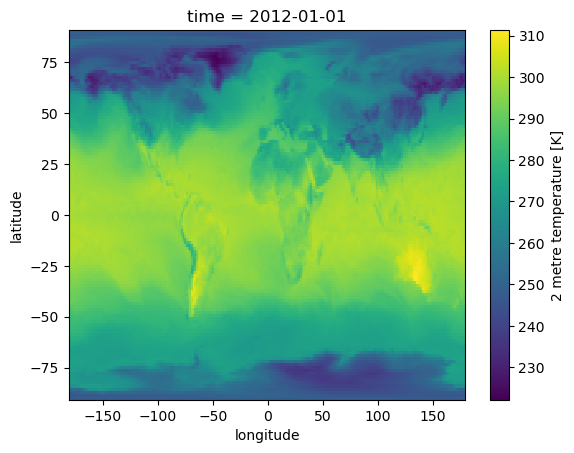

In [7]:
t2m_era5.isel(time=0).plot(x="longitude", y="latitude")

# Dataset analysis

## Dataset info

In [8]:
import numpy as np

logger.start_task("Dataset info ...")


lat_1d = np.flip(t2m_era5.latitude.values)
lon_1d = t2m_era5.longitude.values
dlat = float(np.diff(lat_1d).mean())
dlon = float(np.diff(lon_1d).mean())

times = t2m_era5.time.values
dt_hours = float(np.diff(times[:2]) / np.timedelta64(1, "h"))

logger.info(
    f"\nVariable: 2m_temperature (t2m)\n"
    f"Physical meaning  : Air temperature at 2 metres above the\n"
    f"Units             : {t2m_era5.attrs.get('units', 'K (Kelvin)')}\n"
    f"Spatial resolution:\n"
    f" - Latitude  : {len(lat_1d)} points, step ≈ {dlat:.2f}°  (~{abs(dlat)*111:.0f} km at equator)\n"
    f" - Longitude : {len(lon_1d)} points, step ≈ {dlon:.2f}°  (~{abs(dlon)*111:.0f} km at equator)\n"
    f" - Approx. 1.5° / 150 km equiangular grid\n"
    f"Temporal resolution:\n"
    f" - Time step  : {dt_hours:.0f} hours (6-hourly)\n"
    f" - Period     : {str(times[0])[:10]}  →  {str(times[-1])[:10]}\n"
    f"  Time steps: {t2m_era5.time.size}"
)
logger.success("Data info on screen.")

╭────── TASK STARTED ───────╮
│                           │
│    🚀 Dataset info ...    │
│                           │
│    🕒 13:34:10            │
│                           │
│                           │
╰───────────────────────────╯

/tmp/ipykernel_1427587/3222735941.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dt_hours = float(np.diff(times[:2]) / np.timedelta64(1, 'h'))


[INFO] 
Variable: 2m_temperature (t2m)
Physical meaning  : Air temperature at 2 metres above the
Units             : K
Spatial resolution:
 - Latitude  : 121 points, step ≈ -1.50°  (~166 km at equator)
 - Longitude : 240 points, step ≈ 1.50°  (~166 km at equator)
 - Approx. 1.5° / 150 km equiangular grid
Temporal resolution:
 - Time step  : 6 hours (6-hourly)
 - Period     : 2012-01-01  →  2021-12-31
  Time steps: 14612

✅ Data info on screen.

## Statistical info

In [9]:
logger.start_task("Global Statistical Description (2012–2022) ...")

# Flatten all values for global statistics (time × lat × lon)
vals = t2m_era5.values.ravel()

mean = float(np.mean(vals))
std = float(np.std(vals))
vmin = float(np.min(vals))
vmax = float(np.max(vals))
pcts = np.percentile(vals, [5, 25, 50, 75, 95])

logger.info(
    f"\n  Mean         : {mean:8.2f} K  ({mean-273.15:+.2f} °C)\n"
    f"  Std          : {std:8.2f} K\n"
    f"  Min          : {vmin:8.2f} K  ({vmin-273.15:+.2f} °C)\n"
    f"  Max          : {vmax:8.2f} K  ({vmax-273.15:+.2f} °C)\n"
    f"  5th  pct     : {pcts[0]:8.2f} K  ({pcts[0]-273.15:+.2f} °C)\n"
    f"  25th pct     : {pcts[1]:8.2f} K  ({pcts[1]-273.15:+.2f} °C)\n"
    f"  50th pct     : {pcts[2]:8.2f} K  ({pcts[2]-273.15:+.2f} °C)\n"
    f"  75th pct     : {pcts[3]:8.2f} K  ({pcts[3]-273.15:+.2f} °C)\n"
    f"  95th pct     : {pcts[4]:8.2f} K  ({pcts[4]-273.15:+.2f} °C"
)
logger.success("Statistical description completed.")

╭───────────────────── TASK STARTED ──────────────────────╮
│                                                         │
│    🚀 Global Statistical Description (2012–2022) ...    │
│                                                         │
│    🕒 13:34:10                                          │
│                                                         │
│                                                         │
╰─────────────────────────────────────────────────────────╯

[INFO] 
  Mean         :   278.69 K  (+5.54 °C)
  Std          :    21.32 K
  Min          :   191.54 K  (-81.61 °C)
  Max          :   325.30 K  (+52.15 °C)
  5th  pct     :   234.87 K  (-38.28 °C)
  25th pct     :   268.92 K  (-4.23 °C)
  50th pct     :   283.48 K  (+10.33 °C)
  75th pct     :   296.57 K  (+23.42 °C)
  95th pct     :   301.13 K  (+27.98 °C

✅ Statistical description completed.

## Coarsening 

In [10]:
from IPSL_AID.dataset import coarse_down_up

logger.start_task("Applying a coarse up-down ...")

# t2m_era5.values shape: (time, lon, lat) → acts as (C, W, H) where C = time
coarse_up_tensor = coarse_down_up(
    fine_filtered=t2m_era5.values,
    fine_batch=t2m_era5.values,
    input_shape=(32, 16),  # (lon, lat) to match data order
    axis=0,
)

t2m_smooth = xr.DataArray(
    coarse_up_tensor.numpy(),
    coords=t2m_era5.coords,
    dims=t2m_era5.dims,
    attrs=t2m_era5.attrs,
    name="t2m_coarse_up",
)

╭───────────── TASK STARTED ─────────────╮
│                                        │
│    🚀 Applying a coarse up-down ...    │
│                                        │
│    🕒 13:34:23                         │
│                                        │
│                                        │
╰────────────────────────────────────────╯

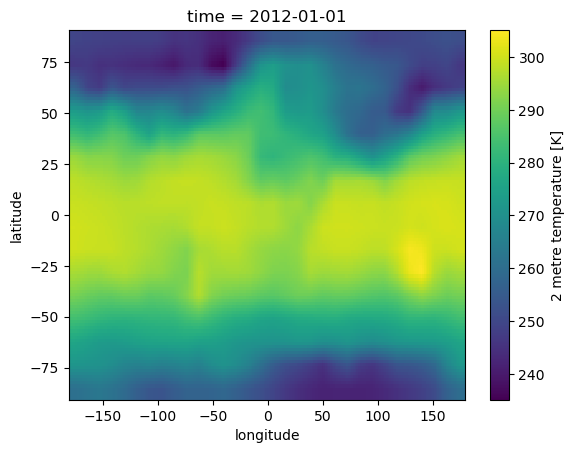

In [11]:
t2m_smooth.isel(time=0).plot(x="longitude", y="latitude")

✅ Data smoothing completed.

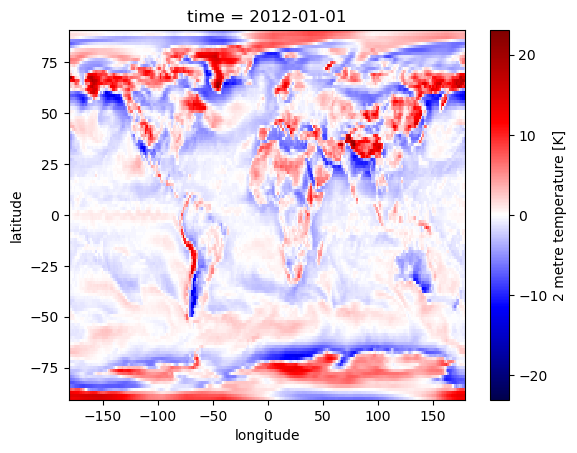

In [12]:
(t2m_smooth - t2m_era5).isel(time=0).plot(x="longitude", y="latitude", cmap="seismic")
logger.success("Data smoothing completed.")

### Data splitting and normalization

In [13]:
logger.start_task("Data splitting and normalization ...")

#   Train : 2015–2019  (5 years)
X_train = t2m_smooth.sel(time=slice("2015", "2019")).values
y_train = t2m_era5.sel(time=slice("2015", "2019")).values

#   Val   : 2020       (one year)
X_val = t2m_smooth.sel(time=slice("2020", "2020")).values
y_val = t2m_era5.sel(time=slice("2020", "2020")).values

#   Test  : 2021       (one year)
X_test = t2m_smooth.sel(time=slice("2021", "2021")).values
y_test = t2m_era5.sel(time=slice("2021", "2021")).values


# mean & std
y_mean = y_train.mean()
y_std = y_train.std()


# normalize
def normalize(arr):
    return (arr - y_mean) / y_std


# denormalize
def denormalize(arr):
    return arr * y_std + y_mean


# Normalize input (smooth) and target (fine) fields
X_train_n = normalize(X_train).astype(np.float32)
y_train_n = normalize(y_train).astype(np.float32)

X_val_n = normalize(X_val).astype(np.float32)
y_val_n = normalize(y_val).astype(np.float32)

X_test_n = normalize(X_test).astype(np.float32)
y_test_n = normalize(y_test).astype(np.float32)

logger.info(
    f"\nTrain : X={X_train.shape}, y={y_train.shape}\n"
    f"Val   : X={X_val.shape}, y={y_val.shape}\n"
    f"Test  : X={X_test.shape}, y={y_test.shape}\n"
    f"Normalized X_train  mean={X_train_n.mean():.4f}, std={X_train_n.std():.4f}\n"
    f"Normalized y_train  mean={y_train_n.mean():.4f}, std={y_train_n.std():.4f}"
)
logger.success("Data splitting and normalization completed.")

╭──────────────── TASK STARTED ─────────────────╮
│                                               │
│    🚀 Data splitting and normalization ...    │
│                                               │
│    🕒 13:34:27                                │
│                                               │
│                                               │
╰───────────────────────────────────────────────╯

[INFO] 
Train : X=(7304, 240, 121), y=(7304, 240, 121)
Val   : X=(1464, 240, 121), y=(1464, 240, 121)
Test  : X=(1460, 240, 121), y=(1460, 240, 121)
Normalized X_train  mean=0.0023, std=0.9461
Normalized y_train  mean=-0.0000, std=1.0000

✅ Data splitting and normalization completed.

## Dataset pipeline

In [14]:
import torch
from torch.utils.data import Dataset, DataLoader

logger.start_task("Building the data loaders ...")

# detect the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"\nDevice: {device}")


class T2mDataset(Dataset):
    """Each sample is one time step: (smooth_field, fine_field)."""

    def __init__(self, X: np.ndarray, y: np.ndarray, logger: None):
        # Original:
        # (T, lon, lat)

        # (T, lat, lon)
        X = np.transpose(X, (0, 2, 1))
        y = np.transpose(y, (0, 2, 1))

        # Crop latitude: 121 -> 120
        X = X[:, :120, :]
        y = y[:, :120, :]

        # add channel dim → (T, 1, lat, lon)
        self.X = torch.from_numpy(X[:, None])
        self.y = torch.from_numpy(y[:, None])

        logger.info(f"\nTensor X: {self.X.shape}\n" f"Tensor y: {self.y.shape}")
        self.img_lat = X.shape[1]
        self.img_lon = X.shape[2]

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH = 16

train_ds = T2mDataset(X_train_n, y_train_n, logger)
val_ds = T2mDataset(X_val_n, y_val_n, logger)
test_ds = T2mDataset(X_test_n, y_test_n, logger)

train_loader = DataLoader(
    train_ds, batch_size=BATCH, shuffle=True, num_workers=4, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH, shuffle=False, num_workers=4, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH, shuffle=False, num_workers=4, pin_memory=True
)

img_lat = train_ds.img_lat
img_lon = train_ds.img_lon

logger.info(f"\nImage resolution: {img_lat} x {img_lon}")
logger.info(
    f"\nTrain size: {len(train_loader)} ~ Number of train years × time steps per year / batch size\n"
    f"Validation size: {len(val_loader)} ~ Number of validation years × time steps per year / batch size\n"
    f"Test size: {len(test_loader)} ~ Number of test years × time steps per year / batch size"
)

logger.success("Data loaders are built.")

╭───────────── TASK STARTED ─────────────╮
│                                        │
│    🚀 Building the data loaders ...    │
│                                        │
│    🕒 13:34:31                         │
│                                        │
│                                        │
╰────────────────────────────────────────╯

[INFO] 
Device: cuda

[INFO] 
Tensor X: torch.Size([7304, 1, 120, 240])
Tensor y: torch.Size([7304, 1, 120, 240])

[INFO] 
Tensor X: torch.Size([1464, 1, 120, 240])
Tensor y: torch.Size([1464, 1, 120, 240])

[INFO] 
Tensor X: torch.Size([1460, 1, 120, 240])
Tensor y: torch.Size([1460, 1, 120, 240])

[INFO] 
Image resolution: 120 x 240

[INFO] 
Train size: 457 ~ Number of train years × time steps per year / batch size
Validation size: 92 ~ Number of validation years × time steps per year / batch size
Test size: 92 ~ Number of test years × time steps per year / batch size

✅ Data loaders are built.

## Model, loss, and metrics

In [15]:
import argparse
from IPSL_AID.utils import EasyDict
from IPSL_AID.model import load_model_and_loss
from IPSL_AID.evaluater import (
    mae_all,
    nmae_all,
    rmse_all,
    r2_all,
    pearson_all,
    kl_divergence_all,
    MetricTracker,
)

logger.start_task("Building NN model, loss, and metrics ...")

var = "2m_temperature"
num_epochs = 15

# args to save model
args = argparse.Namespace()
args.prefix = "test_run"
args.save_checkpoint_name = "model_song"
args.num_epochs = num_epochs

# Setup training state tracking
start_epoch = 0
samples_processed = 0
batches_processed = 0
avg_val_loss = float("inf")
best_val_loss = float("inf")
avg_epoch_loss = float("inf")
best_epoch = 0

# a light, but still good work
opts = EasyDict(
    {
        "arch": "ddpmpp",
        "precond": "unet",
        "img_resolution": (img_lat, img_lon),
        "in_channels": 1,
        "out_channels": 1,
        "label_dim": 0,
        "model_kwargs": {
            "model_channels": 32,
            "channel_mult": [1, 2, 4],
            "num_blocks": 2,
            "attn_resolutions": [],
        },
    }
)

# wrap the model, and its loss
model, loss_fn = load_model_and_loss(opts, logger, device)

model = model.to(device)

# what metrics?
metric_names = ["MAE", "NMAE", "RMSE", "R2", "PEARSON", "KL"]

# their corresponding functions
metric_funcs = {
    "MAE": mae_all,
    "NMAE": nmae_all,
    "RMSE": rmse_all,
    "R2": r2_all,
    "PEARSON": pearson_all,
    "KL": kl_divergence_all,
}

metrics_keys = []
for m in metric_names:
    metrics_keys.append(f"{var}_pred_vs_fine_{m}")
    metrics_keys.append(f"{var}_coarse_vs_fine_{m}")

# for train
train_metrics = {f"{m}": MetricTracker() for m in metrics_keys}

# for validation
valid_metrics = {f"{m}": MetricTracker() for m in metrics_keys}

# for test
test_metrics = {f"{m}": MetricTracker() for m in metrics_keys}

# metric history
train_metrics_history = {key: [] for key in metrics_keys}
valid_metrics_history = {key: [] for key in metrics_keys}

# loss history
train_loss_history = [0] * num_epochs
valid_loss_history = [0] * num_epochs

# tracker
train_loss = MetricTracker()
valid_loss = MetricTracker()

logger.info(f"Metrics: {metrics_keys}")

# optimier & scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5
)

if device.type == "cuda":
    from torch.amp import GradScaler

    scaler = GradScaler("cuda")
    logger.info("GradScaler initialized for CUDA")
else:
    scaler = None
    logger.info("GradScaler disabled (AMP not supported on CPU)")


logger.success("Building NN model, loss, and metrics completed.")

╭────────────────── TASK STARTED ───────────────────╮
│                                                   │
│    🚀 Building NN model, loss, and metrics ...    │
│                                                   │
│    🕒 13:34:33                                    │
│                                                   │
│                                                   │
╰───────────────────────────────────────────────────╯

[INFO] Using direct U-Net & UnetLoss

[INFO] Architecture DDPM++ / SongUNet selected for direct U-Net

[INFO] Overriding with user model_kwargs

[INFO] Instantiating model...

...

[INFO] Loss function instantiated: UnetLoss

[INFO]   └── Loss Type: UNET Diffusion Loss

[INFO] Metrics: ['2m_temperature_pred_vs_fine_MAE', '2m_temperature_coarse_vs_fine_MAE', 
'2m_temperature_pred_vs_fine_NMAE', '2m_temperature_coarse_vs_fine_NMAE', '2m_temperature_pred_vs_fine_RMSE', 
'2m_temperature_coarse_vs_fine_RMSE', '2m_temperature_pred_vs_fine_R2', '2m_temperature_coarse_vs_fine_R2', 
'2m_temperature_pred_vs_fine_PEARSON', '2m_temperature_coarse_vs_fine_PEARSON', '2m_temperature_pred_vs_fine_KL', 
'2m_temperature_coarse_vs_fine_KL']

[INFO] GradScaler initialized for CUDA

✅ Building NN model, loss, and metrics completed.

## Training pipeline

In [16]:
import time
from tqdm import tqdm
from IPSL_AID.model_utils import ModelUtils


logger.start_task("Start training ...")

for epoch in range(start_epoch, num_epochs):
    model.train()

    # Reset trackers
    train_loss.reset()
    valid_loss.reset()

    for meter in train_metrics.values():
        meter.reset()
    for meter in valid_metrics.values():
        meter.reset()

    previous_time = time.time()

    train_loop = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f"Training Epoch {epoch}",
    )

    for batch_idx, (xb, yb) in train_loop:
        xb, yb = xb.to(device), yb.to(device)
        if epoch == 0 and batch_idx == 0:
            logger.info(
                f"batch idx:{batch_idx}, features shape:{xb.shape}, targets shape:{yb.shape}"
            )
        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(model, yb, xb)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss.update(loss.item(), yb.shape[0])

        # Calculate all metrics
        for metric_name in metric_names:
            metric_func = metric_funcs[metric_name]

            # Prediction vs fine
            num_elements_pred, metric_value_pred = metric_func(pred, yb)
            train_metrics[f"{var}_pred_vs_fine_{metric_name}"].update(
                metric_value_pred.item(), num_elements_pred
            )

            # Coarse vs fine
            num_elements_coarse, metric_value_coarse = metric_func(xb, yb)
            train_metrics[f"{var}_coarse_vs_fine_{metric_name}"].update(
                metric_value_coarse.item(), num_elements_coarse
            )

        current_time = time.time()
        batch_time = current_time - previous_time
        previous_time = current_time

        # Progress bar
        train_loop.set_postfix(
            {
                "Loss": f"{loss.item():.4f}",
                "Avg Loss": f"{train_loss.getmean():.4f}",
                "Time": f"{batch_time:.2f}s",
            }
        )

    avg_epoch_loss = train_loss.getmean()
    train_loss_history[epoch] = avg_epoch_loss

    model.eval()
    logger.info(f"Running validation for epoch {epoch}...")

    with torch.no_grad():
        valid_loop = tqdm(
            enumerate(val_loader),
            total=len(val_loader),
            desc=f"Validation Epoch {epoch}",
        )

        for batch_idx, (xb, yb) in valid_loop:
            xb, yb = xb.to(device), yb.to(device)
            if epoch == 0 and batch_idx == 0:
                logger.info(
                    f"Validation batch idx:{batch_idx}\n"
                    f"features shape:{xb.shape}, targets shape:{yb.shape}"
                )

            pred = model(xb)
            loss = loss_fn(model, yb, xb)
            valid_loss.update(loss.item(), yb.shape[0])
            valid_loop.set_postfix(
                {
                    "Val Loss": f"{loss.item():.4f}",
                    "Avg Val Loss": f"{valid_loss.getmean():.4f}",
                }
            )
            # Calculate all metrics
            for metric_name in metric_names:
                metric_func = metric_funcs[metric_name]

                # Prediction vs fine
                num_elements_pred, metric_value_pred = metric_func(pred, yb)
                valid_metrics[f"{var}_pred_vs_fine_{metric_name}"].update(
                    metric_value_pred.item(), num_elements_pred
                )

                # Coarse vs fine
                num_elements_coarse, metric_value_coarse = metric_func(xb, yb)
                valid_metrics[f"{var}_coarse_vs_fine_{metric_name}"].update(
                    metric_value_coarse.item(), num_elements_coarse
                )

    avg_val_loss = valid_loss.getmean()
    valid_loss_history[epoch] = avg_val_loss
    scheduler.step(avg_val_loss)

    # Metrics history
    for key in train_metrics:
        train_value = train_metrics[key].getmean()
        valid_value = valid_metrics[key].getmean()

        train_metrics_history[key].append(train_value)
        valid_metrics_history[key].append(valid_value)

        if epoch == num_epochs - 1:
            logger.info(f"  {key}: train={train_value:.6e}, valid={valid_value:.6e}")

    # Save best model
    if val_loader is not None and avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch

        ModelUtils.save_training_checkpoint(
            model=model,
            optimizer=optimizer,
            epoch=epoch,
            samples_processed=samples_processed,
            batches_processed=batches_processed,
            train_loss_history=train_loss_history,
            valid_loss_history=valid_loss_history,
            valid_metrics_history=valid_metrics_history,
            best_val_loss=best_val_loss,
            best_epoch=best_epoch,
            avg_val_loss=avg_val_loss,
            avg_epoch_loss=avg_epoch_loss,
            args=args,
            paths=EasyDict({"checkpoints": "./checkpoints"}),
            logger=logger,
            checkpoint_type="best",
            save_full_model=False,
        )

logger.success("Training successfully completed.")

╭─────── TASK STARTED ────────╮
│                             │
│    🚀 Start training ...    │
│                             │
│    🕒 13:34:33              │
│                             │
│                             │
╰─────────────────────────────╯

I0526 13:34:33.578878 1427587 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0526 13:34:33.629323 1427587 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0526 13:34:33.689201 1427587 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0526 13:34:33.730899 1427587 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
Training Epoch 0:   0%|          | 0/457 [00:00<?, ?it/s]

[INFO] batch idx:0, features shape:torch.Size([16, 1, 120, 240]), targets shape:torch.Size([16, 1, 120, 240])

Training Epoch 0: 100%|██████████| 457/457 [02:04<00:00,  3.66it/s, Loss=0.0092, Avg Loss=0.0231, Time=0.26s]


[INFO] Running validation for epoch 0...

...

[INFO]   2m_temperature_pred_vs_fine_PEARSON: train=9.985798e-01, valid=9.980980e-01

[INFO]   2m_temperature_coarse_vs_fine_PEARSON: train=9.867086e-01, valid=9.866214e-01

[INFO]   2m_temperature_pred_vs_fine_KL: train=2.658993e-03, valid=3.804453e-03

[INFO]   2m_temperature_coarse_vs_fine_KL: train=3.559299e-02, valid=1.902531e-01

✅ Training successfully completed.

## Plot histories

╭────────────── TASK STARTED ──────────────╮
│                                          │
│    🚀 Start ploting the histories ...    │
│                                          │
│    🕒 14:08:22                           │
│                                          │
│                                          │
╰──────────────────────────────────────────╯

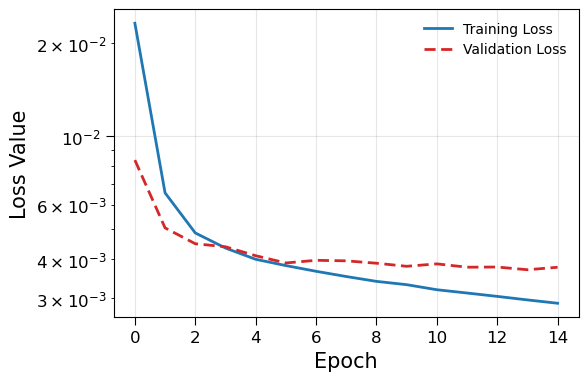

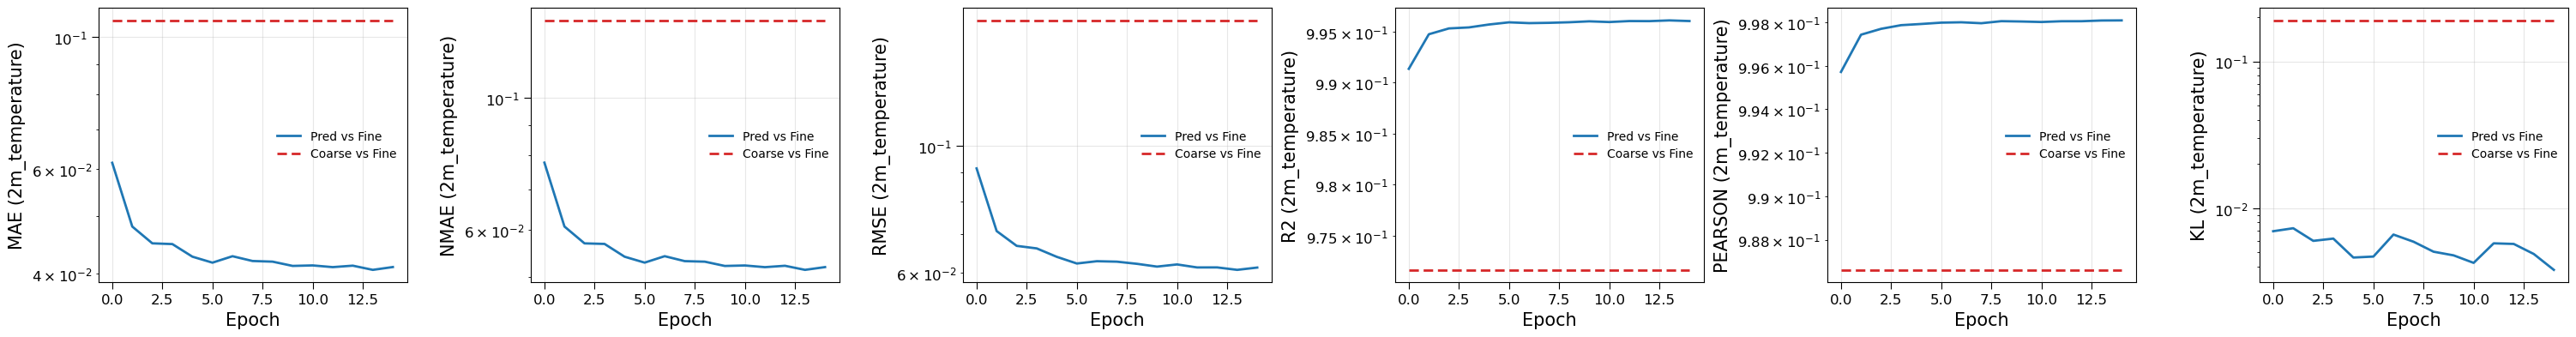

✅ Histories are plotted.

In [17]:
from IPSL_AID.diagnostics import plot_loss_histories, plot_metric_histories
from IPython.display import Image, display

logger.start_task("Start ploting the histories ...")

# losses
history_plot_path = plot_loss_histories(
    train_loss_history,
    valid_loss_history,
    filename="training_validation_loss.png",
    save_dir="./results",
)

display(Image(filename=history_plot_path))

# metrics
plot_metric_path = plot_metric_histories(
    valid_metrics_history,
    [var],
    metric_names,
    filename="validation_metrics",
    save_dir="./results",
)
display(Image(filename=plot_metric_path))
logger.success("Histories are plotted.")

## Evaluation on test data

In [18]:
logger.start_task("Start evaluation on the test data ...")
checkpoint_path = "./checkpoints/test_run_best_model.pth.tar"
if os.path.exists(checkpoint_path):
    (
        epoch,
        samples_processed,
        batches_processed,
        best_val_loss,
        best_epoch,
        checkpoint,
    ) = ModelUtils.load_training_checkpoint(
        checkpoint_path, model, optimizer, device, logger=logger
    )

model.eval()
all_preds = []
with torch.no_grad():
    test_loop = tqdm(
        enumerate(test_loader),
        total=len(test_loader),
        desc="Test",
    )
    for meter in test_metrics.values():
        meter.reset()

    for batch_idx, (xb, yb) in test_loop:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)

        # Calculate all metric
        for metric_name in metric_names:
            metric_func = metric_funcs[metric_name]

            # Model prediction vs fine
            num_elements_pred, metric_value_pred = metric_func(pred, yb)
            test_metrics[f"{var}_pred_vs_fine_{metric_name}"].update(
                metric_value_pred.item(), num_elements_pred
            )

            # Coarse vs fine (baseline metric)
            num_elements_coarse, metric_value_coarse = metric_func(xb, yb)
            test_metrics[f"{var}_coarse_vs_fine_{metric_name}"].update(
                metric_value_coarse.item(), num_elements_coarse
            )

        all_preds.append(pred.cpu().numpy())

# Test metrics
for key in test_metrics:
    test_value = test_metrics[key].getmean()
    logger.info(f"  {key}: test={test_value:.6e}")


all_preds = np.concatenate(all_preds, axis=0)
predictions = denormalize(all_preds)

# (T, lat, lon)
X_test = np.transpose(X_test, (0, 2, 1))
y_test = np.transpose(y_test, (0, 2, 1))
X_test = X_test[:, :120, :]
y_test = y_test[:, :120, :]

# add channel dim → (T, 1, lat, lon)
coarses = X_test[:, None]
targets = y_test[:, None]

logger.success("Evaluation on test done.")

╭───────────────── TASK STARTED ─────────────────╮
│                                                │
│    🚀 Start evaluation on the test data ...    │
│                                                │
│    🕒 14:08:23                                 │
│                                                │
│                                                │
╰────────────────────────────────────────────────╯

[INFO] Loading checkpoint from: './checkpoints/test_run_best_model.pth.tar'

/home/kardaneh/.local/lib/python3.12/site-packages/IPSL_AID/model_utils.py:200: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_lo

[INFO] Checkpoint loaded into memory

[INFO] Checkpoint keys: ['epoch', 'state_dict', 'optimizer', 'samples_processed', 'batches_processed', 
'train_loss_history', 'valid_loss_history', 'valid_metrics_history', 'best_val_loss', 'best_epoch', 'val_loss', 
'train_loss', 'checkpoint_type', 'timestamp', 'args']

...

[INFO]   2m_temperature_pred_vs_fine_PEARSON: test=9.981069e-01

[INFO]   2m_temperature_coarse_vs_fine_PEARSON: test=9.869221e-01

[INFO]   2m_temperature_pred_vs_fine_KL: test=5.611015e-03

[INFO]   2m_temperature_coarse_vs_fine_KL: test=1.635409e-01

✅ Evaluation on test done.

## Diagnostics

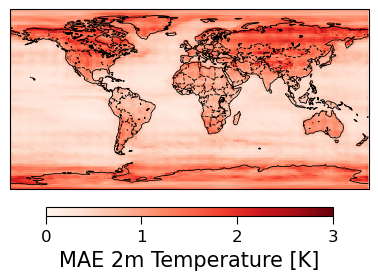

[PDF stats] 2m Temperature [K]
  Predictions: μ=278.823, σ=21.504
  Ground Truth: μ=278.747, σ=21.558
  Coarse: μ=278.798, σ=20.383
  KL Divergence: 0.0016
  Correlation: 0.9981


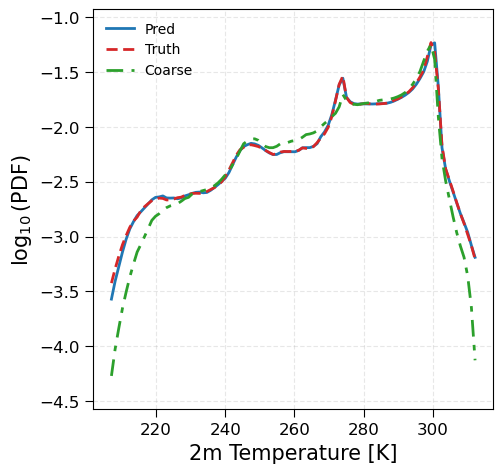

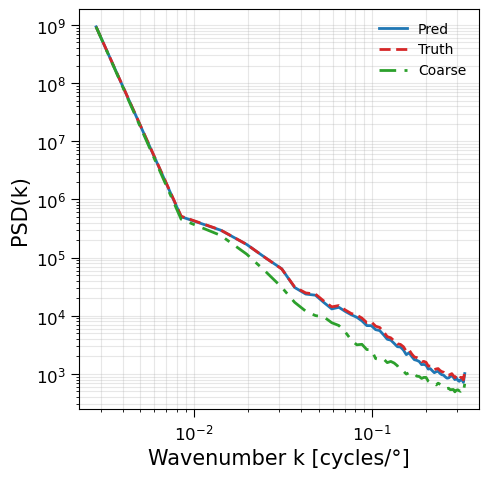

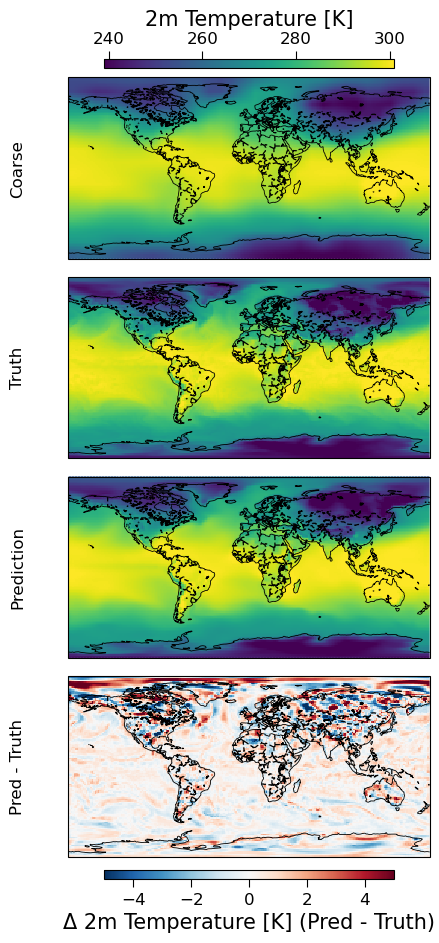

[QQ Quantiles] 2m Temperature [K]
  q=0.900 | Truth=300.0551 | Pred=300.2401 | Coarse=299.5552 
  q=0.950 | Truth=301.1119 | Pred=301.1266 | Coarse=300.4923 
  q=0.975 | Truth=302.3896 | Pred=302.3781 | Coarse=301.3233 
  q=0.990 | Truth=306.1585 | Pred=306.2368 | Coarse=303.4477 
  q=0.995 | Truth=308.9095 | Pred=309.0663 | Coarse=305.4110 


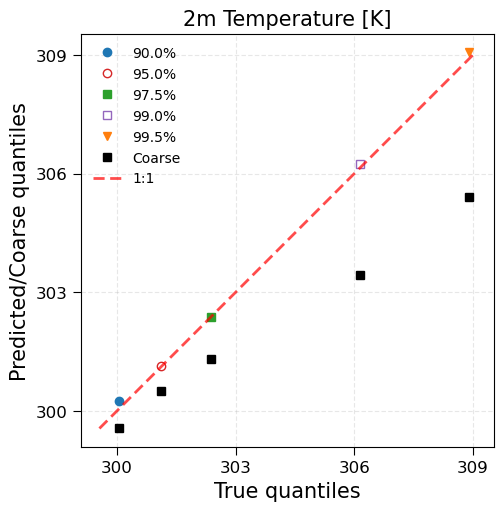

In [25]:
from IPSL_AID.diagnostics import (
    plot_power_spectra,
    plot_surface,
    plot_validation_pdfs,
    plot_MAE_map,
    plot_qq_quantiles,
)
from IPython.display import Image, display

error_plot_path = plot_MAE_map(
    predictions=predictions[:, :, ::-1, :],
    targets=targets[:, :, ::-1, :],
    lat_1d=lat_1d,
    lon_1d=lon_1d,
    variable_names=["T2M"],
    save_dir="./results",
    filename="songunet_error_map.png",
    figsize_multiplier=5,
)

display(Image(filename=error_plot_path))

pdf_plot_path = plot_validation_pdfs(
    predictions=predictions[:, :, ::-1, :],
    targets=targets[:, :, ::-1, :],
    coarse_inputs=coarses[:, :, ::-1, :],
    variable_names=["T2M"],
    save_dir="./results",
    filename="songunet_t2m_pdf.png",
    figsize_multiplier=5,
)

display(Image(filename=pdf_plot_path))

psd_plot_path = plot_power_spectra(
    predictions=predictions[:, :, ::-1, :],
    targets=targets[:, :, ::-1, :],
    coarse_inputs=coarses[:, :, ::-1, :],
    dlat=dlat,
    dlon=dlon,
    variable_names=["T2M"],
    filename="songunet_t2m_power_spectra.png",
    save_dir="./results",
    figsize_multiplier=5,
)

display(Image(filename=psd_plot_path))

expected_path = plot_surface(
    coarse_inputs=coarses[0:1, 0:1, ::-1, :],
    targets=targets[0:1, 0:1, ::-1, :],
    predictions=predictions[0:1, 0:1, ::-1, :],
    lat_1d=lat_1d,
    lon_1d=lon_1d,
    timestamp=None,
    variable_names=["T2M"],
    filename="plot_surface_standard.png",
    save_dir="./results",
    figsize_multiplier=5,
)
display(Image(filename=expected_path))

qq_plot_path = plot_qq_quantiles(
    predictions=predictions[:, :, ::-1, :],
    targets=targets[:, :, ::-1, :],
    coarse_inputs=coarses[:, :, ::-1, :],
    variable_names=["T2M"],
    quantiles=[0.90, 0.95, 0.975, 0.99, 0.995],
    save_dir="./results",
    filename="qq_quantiles_standard.png",
    figsize_multiplier=5,
)
display(Image(filename=qq_plot_path))